In [1]:
import networkx as nx
import random
import pandas as pd

In [3]:
G = nx.read_edgelist(
    "../data/processed/orkut_largest_community.edgelist",
    nodetype=int
)

print("Nós:", G.number_of_nodes())
print("Arestas:", G.number_of_edges())

Nós: 4785
Arestas: 119891


In [4]:
largest_cc = max(nx.connected_components(G), key=len)

original_size = len(largest_cc)

print("Maior componente original:", original_size)

Maior componente original: 4785


In [5]:
G_random = G.copy()

n_remove = int(0.05 * G.number_of_nodes())

random_nodes = random.sample(
    list(G_random.nodes()),
    n_remove
)

G_random.remove_nodes_from(random_nodes)

largest_after_random = len(
    max(nx.connected_components(G_random), key=len)
)

print("Maior componente após remoção aleatória:")
print(largest_after_random)

Maior componente após remoção aleatória:
4527


In [6]:
robust_random = largest_after_random / original_size

print("Robustez aleatória:")
print(robust_random)

Robustez aleatória:
0.9460815047021943


In [9]:
centrality = nx.degree_centrality(G)

sorted_nodes = sorted(
    centrality.items(),
    key=lambda x: x[1],
    reverse=True
)

top_nodes = [
    node
    for node, _ in sorted_nodes[:n_remove]
]

print("Nós removidos:", len(top_nodes))

Nós removidos: 239


In [10]:
G_attack = G.copy()

G_attack.remove_nodes_from(top_nodes)

largest_after_attack = len(
    max(nx.connected_components(G_attack), key=len)
)

print("Maior componente após ataque direcionado:")
print(largest_after_attack)

Maior componente após ataque direcionado:
4505


In [11]:
robust_attack = largest_after_attack / original_size

print("Robustez ataque direcionado:")
print(robust_attack)

Robustez ataque direcionado:
0.9414838035527691


In [12]:
results = pd.DataFrame({
    "Cenário": [
        "Original",
        "Remoção Aleatória 5%",
        "Remoção Top 5% Centrais"
    ],
    "Maior Componente": [
        original_size,
        largest_after_random,
        largest_after_attack
    ]
})

results

,Cenário,Maior Componente
0,Original,4785
1,Remoção Aleatória 5%,4527
2,Remoção Top 5% Centrais,4505


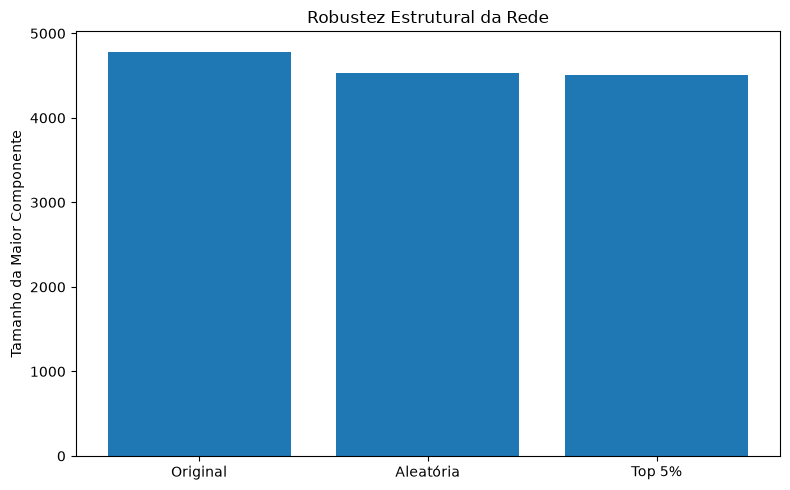

In [13]:
import matplotlib.pyplot as plt

labels = [
    "Original",
    "Aleatória",
    "Top 5%"
]

values = [
    original_size,
    largest_after_random,
    largest_after_attack
]

plt.figure(figsize=(8,5))
plt.bar(labels, values)

plt.ylabel("Tamanho da Maior Componente")
plt.title("Robustez Estrutural da Rede")

plt.tight_layout()

plt.savefig(
    "../figures/robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()